# DeepSDF Airport - Pipeline principal

## Cell 0 - Objectif du notebook

Ce notebook couvre la chaîne principale du projet:

- ingestion de données géométriques aéroportuaires ;
- extrusion 3D ;
- échantillonnage SDF ;
- entraînement d'un modèle DeepSDF ;
- validation géométrique ;
- visualisation par ray marching ;
- génération d'un masque d'obstacles ;
- test d'intégration avec `wind.py`.


## Cell 1 - Paramètres d'exécution

- fichier : `data_sources/airport_study.alaqs`
- configuration principale : `config.yaml`
- `USE_TEST_CUBE = True` pour un test technique


In [1]:
USE_GOOGLE_DRIVE = True
DRIVE_PROJECT_DIR = "/content/drive/MyDrive/deepsdf_airport"
USE_TEST_CUBE = False

CONFIG_FILE = "config.yaml"



## Cell 2 - Préparation du workspace


In [3]:
import os
import sys
import json
import shutil
from pathlib import Path
import yaml

IN_COLAB = "google.colab" in sys.modules
SOURCE_DIR = Path.cwd()

if IN_COLAB and USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    SOURCE_DIR = Path(DRIVE_PROJECT_DIR)

WORK_DIR = Path("/content/deepsdf_airport") if IN_COLAB else (SOURCE_DIR / "COLAB_RUN")
WORK_DIR.mkdir(parents=True, exist_ok=True)

for sub in ["data/meshes", "data/sdf_dataset", "checkpoints", "outputs", "data_sources"]:
    path = WORK_DIR / sub
    if path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)

required_files = [
    "config.yaml",
    "requirements.txt",
    "utils.py",
    "openalaqs_import.py",
    "data_ingestion.py",
    "sdf_sampling.py",
    "deepsdf_model.py",
    "train.py",
    "visualize.py",
    "generate_mask.py",
    "evaluate_reconstruction.py",
]

missing = [name for name in required_files if not (SOURCE_DIR / name).exists()]
if missing:
    raise FileNotFoundError(f"Fichiers manquants dans le dossier source : {missing}")

for name in required_files:
    shutil.copy2(SOURCE_DIR / name, WORK_DIR / name)

with open(SOURCE_DIR / CONFIG_FILE, "r", encoding="utf-8") as f:
    selected_cfg = yaml.safe_load(f)

airport_cfg = selected_cfg.get("airport", {})
openalaqs_rel = airport_cfg.get("open_alaqs_database", "") or airport_cfg.get("open_alaqs_study", "")

if not USE_TEST_CUBE and not openalaqs_rel:
    raise ValueError("config.yaml doit définir airport.open_alaqs_database")

if openalaqs_rel:
    src = SOURCE_DIR / openalaqs_rel
    if not src.exists():
        raise FileNotFoundError(f"Étude OpenALAQS introuvable : {src}")
    dst = WORK_DIR / openalaqs_rel
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)

prof_src = SOURCE_DIR / "prof_files"
if prof_src.exists():
    prof_dst = WORK_DIR / "prof_files"
    if prof_dst.exists():
        shutil.rmtree(prof_dst)
    shutil.copytree(prof_src, prof_dst)

os.chdir(WORK_DIR)
print("Workspace prêt :", WORK_DIR)
print("Configuration choisie :", CONFIG_FILE)
if openalaqs_rel:
    print("Étude OpenALAQS copiée :", openalaqs_rel)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Workspace prêt : /content/deepsdf_airport
Configuration choisie : config.yaml
Étude OpenALAQS copiée : data_sources/airport_study.alaqs


## Cell 3 - Dépendances


In [4]:
import sys
!{sys.executable} -m pip install -q -r requirements.txt
print("Dépendances prêtes.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 11.5 MB/s eta 0:00:00
Dépendances prêtes.


## Cell 3b - Préflight des dépendances et de la base OpenALAQS

Cette étape vérifie les modules critiques et confirme que l'étude `.alaqs` fournie manuellement est bien détectée avant le lancement du pipeline.


In [5]:
import importlib
from pathlib import Path

required_modules = ['torch', 'numpy', 'trimesh', 'shapely', 'yaml', 'scipy', 'skimage', 'matplotlib', 'imageio', 'imageio_ffmpeg', 'rtree']
for name in required_modules:
    mod = importlib.import_module(name)
    version = getattr(mod, "__version__", "unknown")
    print(f"{name}: {version}")

with open(CONFIG_FILE, "r", encoding="utf-8") as f:
    selected_cfg = yaml.safe_load(f)

airport_cfg = selected_cfg.get("airport", {})
openalaqs_rel = airport_cfg.get("open_alaqs_database", "") or airport_cfg.get("open_alaqs_study", "")

if USE_TEST_CUBE:
    print("Mode test cube actif.")
else:
    if not openalaqs_rel:
        raise ValueError("config.yaml doit contenir airport.open_alaqs_database")
    study_path = Path(openalaqs_rel)
    if not study_path.exists():
        raise FileNotFoundError(f"Étude OpenALAQS introuvable : {study_path}")
    print("Étude OpenALAQS détectée :", study_path.resolve())


torch: 2.10.0+cu128
numpy: 2.0.2
trimesh: 4.11.5
shapely: 2.1.2
yaml: 6.0.3
scipy: 1.16.3
skimage: 0.25.2
matplotlib: 3.10.0
imageio: 2.37.3
imageio_ffmpeg: 0.6.0
rtree: 1.4.1
Étude OpenALAQS détectée : /content/deepsdf_airport/data_sources/airport_study.alaqs


## Cell 4 - Vérification GPU et configuration


In [6]:
import yaml
import torch
from pprint import pprint

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")
else:
    print("GPU non détecté, exécution CPU.")

with open(CONFIG_FILE, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

print("\nRésumé de configuration :")
pprint({
    "airport": cfg["airport"],
    "sampling": cfg["sampling"],
    "model": cfg["model"],
    "training": cfg["training"],
    "domain": cfg["domain"],
})


GPU : Tesla T4
VRAM: 15.6 GB

Résumé de configuration :
{'airport': {'center_lat': 48.73,
             'center_lon': 2.36,
             'default_height_m': 10.0,
             'footprints_crs_epsg': 4326,
             'footprints_geojson': '',
             'height_per_level_m': 3.5,
             'name': 'Paris-Orly',
             'open_alaqs_database': 'data_sources/airport_study.alaqs',
             'radius_m': 1500},
 'domain': {'grid_nx': 140,
            'grid_ny': 140,
            'grid_nz': 64,
            'x_max': 1500.0,
            'x_min': -1500.0,
            'y_max': 1500.0,
            'y_min': -1500.0,
            'z_max': 200.0},
 'model': {'activation': 'relu',
           'hidden_dim': 512,
           'n_frequencies': 8,
           'n_hidden_layers': 8,
           'skip_connection_at': 4},
 'sampling': {'clamp_distance': 2.0,
              'n_far_points': 400000,
              'n_near_surface_points': 1400000,
              'n_surface_points': 200000,
              'near

## Cell 4b - Vérification de l'étude OpenALAQS

Cette cellule contrôle rapidement que la base `.alaqs` fournie est bien présente et que ses couches principales ne sont pas vides.


In [ ]:
from pathlib import Path
import sqlite3
import yaml

with open(CONFIG_FILE, "r", encoding="utf-8") as f:
    selected_cfg = yaml.safe_load(f)

airport_cfg = selected_cfg.get("airport", {})
openalaqs_rel = airport_cfg.get("open_alaqs_database", "") or airport_cfg.get("open_alaqs_study", "")

if USE_TEST_CUBE:
    print("Pas d'étude OpenALAQS en mode test cube.")
else:
    if not openalaqs_rel:
        raise ValueError("config.yaml doit contenir airport.open_alaqs_database")
    study_path = Path(openalaqs_rel)
    if not study_path.exists():
        raise FileNotFoundError(f"Étude OpenALAQS introuvable : {study_path}")

    print("Étude OpenALAQS prête :", study_path.resolve())
    print("Taille :", round(study_path.stat().st_size / (1024 * 1024), 2), "MB")

    tables_to_check = [
        "shapes_buildings",
        "shapes_runways",
        "shapes_taxiways",
        "shapes_gates",
    ]
    counts = {}
    with sqlite3.connect(study_path) as conn:
        cur = conn.cursor()
        for table in tables_to_check:
            try:
                cur.execute(f"SELECT COUNT(*) FROM {table}")
                counts[table] = int(cur.fetchone()[0])
            except Exception:
                counts[table] = None

    print("Comptage des couches principales :")
    for table, value in counts.items():
        print(f"  {table}: {value}")

    if counts.get("shapes_buildings") in (0, None):
        print("Attention : la couche buildings est vide ou absente.")
    if counts.get("shapes_runways") in (0, None):
        print("Attention : la couche runways est vide ou absente.")
    if counts.get("shapes_taxiways") in (0, None):
        print("Attention : la couche taxiways est vide ou absente.")


Étude OpenALAQS prête : /content/deepsdf_airport/data_sources/airport_study.alaqs
Taille : 20.32 MB
Comptage des couches principales :
  shapes_buildings: 45
  shapes_runways: 3
  shapes_taxiways: 168
  shapes_gates: 29


## Cell 5 - Ingestion et extrusion 3D

Cette étape privilégie une base OpenALAQS. Sinon, elle utilise un GeoJSON local ou OSM comme source de repli.


In [ ]:
extra_args = "--test-cube" if USE_TEST_CUBE else ""
!python data_ingestion.py --config {CONFIG_FILE} {extra_args}


=== Loading OpenALAQS study for Paris-Orly ===
  Database source: /content/deepsdf_airport/data_sources/airport_study.alaqs
  OpenALAQS layer counts: {'buildings': 0, 'gates': 0, 'runways': 0, 'taxiways': 0, 'roadways': 0, 'parking': 0, 'area_sources': 0, 'point_sources': 0}
  No buildings found in OpenALAQS. Falling back to the next available source.
=== Downloading terminal/building footprints for Paris-Orly ===
  Querying Overpass API (radius=1500 m)...
  Got 7070 OSM elements.
  Parsed 672 valid OSM terminal/building polygons.
  Extruding 672 polygons...
  672 meshes created.
  Saved -> /content/deepsdf_airport/data/meshes/Paris-Orly_buildings.obj
  Stats: 672 buildings, 11,252 vertices, 19,816 faces
  OpenALAQS reference summary -> /content/deepsdf_airport/data/meshes/openalaqs_reference_layers.json
=== Done ===


## Cell 6 - Échantillonnage SDF

Cette étape génère le dataset d'entraînement à partir des meshes extrudés.


In [ ]:
!python sdf_sampling.py --config {CONFIG_FILE}


=== Loading meshes ===
  Loaded Paris-Orly_buildings.obj: 11,252 verts / 19,816 faces
  Combined: 11,252 verts / 19,816 faces
  Watertight: True  (False is normal for a multi-building scene)
  2D footprint metadata loaded for 672 buildings
  Normalisation: center=[0.0, 0.0, 100.0], scale=1500.00 m

=== Sampling 200,000 surface points ===
  186,924 surface points kept within domain (93.5%)

=== Sampling 1,400,000 near-surface points (σ=1.125 m) ===
  Computing SDF for near-surface points…
                                            
=== Sampling 400,000 random domain points ===
  Computing SDF for far points…

=== Dataset saved ===
  Shape  : (1986924, 4)
  Path   : /content/deepsdf_airport/data/sdf_dataset/sdf_dataset.pt
  Coords : [-1.000, 1.000]  (normalised)
  SDF    : [-2.0000, 2.0000]
  Inside : 32.9% of points
  |SDF| mean       : 0.8895
  |SDF| median     : 0.6970
  Exact surface    : 21.2%
  Near surface <0.5: 42.7%
  Near surface <1.0: 59.4%
  Clamped to delta : 24.7%


## Cell 7 - Vérification du dataset

On vérifie ici que le dataset SDF a bien été construit, que les coordonnées sont bien normalisées et que le ratio de points intérieurs reste cohérent.


In [ ]:
import torch
from pathlib import Path

ds_path = Path("data/sdf_dataset/sdf_dataset.pt")
assert ds_path.exists(), f"Dataset introuvable : {ds_path}"

ds = torch.load(ds_path, map_location="cpu")
coords_min, coords_max = ds[:, :3].min().item(), ds[:, :3].max().item()
inside_pct = (ds[:, 3] < 0).float().mean().item() * 100

print(f"Shape  : {tuple(ds.shape)}")
print(f"Coords : [{coords_min:.3f}, {coords_max:.3f}]")
print(f"SDF    : [{ds[:,3].min():.4f}, {ds[:,3].max():.4f}]")
print(f"Inside : {inside_pct:.2f}%")

assert coords_max <= 1.1, f"Coordonn?es hors plage : {coords_max:.3f}"
assert inside_pct >= 0.1, "Trop peu de points int?rieurs : v?rifier l'ingestion et le signe du SDF."


Shape  : (1986924, 4)
Coords : [-1.000, 1.000]
SDF    : [-2.0000, 2.0000]
Inside : 32.91%


## Cell 8 - Entraînement du modèle DeepSDF

L'entraînement est réalisé avec séparation train/validation. Le meilleur checkpoint est sélectionné sur la perte de validation.


In [ ]:
!python train.py --config {CONFIG_FILE}


Device: cuda
  GPU: Tesla T4

Loading dataset: /content/deepsdf_airport/data/sdf_dataset/sdf_dataset.pt

Dataset diagnostics:
  mean(|sdf|)            : 0.889541
  median(|sdf|)          : 0.697014
  exact surface zeros    : 21.20%
  near-surface non-zero  : 21.51%
  clamped far samples    : 24.68%
  1,986,924 points loaded
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  Train points: 1,947,186
  Val points  : 39,738
  Batch size  : 16,384
  Surface band: 0.50000
  Parameters  : 1,891,841

Training for 500 epochs  |  clamp delta = 2.0
Selection metric: validati

In [9]:
from pathlib import Path
import shutil

WORK_DIR = Path("/content/deepsdf_airport")
DRIVE_DIR = Path("/content/drive/MyDrive/deepsdf_airport")
CKPT_DIR = WORK_DIR / "checkpoints"
DRIVE_CKPT_DIR = DRIVE_DIR / "checkpoints"

CKPT_DIR.mkdir(parents=True, exist_ok=True)

# Récupère les checkpoints depuis Drive vers le workspace Colab
for path in DRIVE_CKPT_DIR.glob("*.pt"):
    shutil.copy2(path, CKPT_DIR / path.name)

# Choix automatique du meilleur checkpoint de reprise
resume_candidates = []
if (CKPT_DIR / "best.pt").exists():
    resume_candidates.append(CKPT_DIR / "best.pt")

resume_candidates.extend(sorted(CKPT_DIR.glob("checkpoint_epoch_*.pt")))

if not resume_candidates:
    raise FileNotFoundError("Aucun checkpoint trouvé pour reprendre l'entraînement.")

resume_path = resume_candidates[-1]
print(f"Reprise depuis : {resume_path}")

!python train.py --config config.yaml --resume "{resume_path}"


Reprise depuis : /content/deepsdf_airport/checkpoints/checkpoint_epoch_0400.pt
Device: cuda
  GPU: Tesla T4

Loading dataset: /content/deepsdf_airport/data/sdf_dataset/sdf_dataset.pt

Dataset diagnostics:
  mean(|sdf|)            : 0.889541
  median(|sdf|)          : 0.697014
  exact surface zeros    : 21.20%
  near-surface non-zero  : 21.51%
  clamped far samples    : 24.68%
  1,986,924 points loaded
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
  Train points: 1,947,186
  Val points  : 39,738
  Batch size  : 16,384
  Surface band: 0.50000
  Parameters  : 1,89

## Cell 9 - Validation géométrique

Cette étape répond directement à la partie validation du sujet. Elle reconstruit une surface à partir du DeepSDF, calcule une métrique de type Chamfer, compare l'occupation volumique avec la géométrie de référence et sauvegarde les résultats.


In [10]:
!python evaluate_reconstruction.py --config {CONFIG_FILE} --checkpoint checkpoints/best.pt


  Loaded Paris-Orly_buildings.obj: 11,252 verts / 19,816 faces
Device: cuda
Evaluating SDF on validation grid…
Reconstructing mesh with marching cubes…
Computing Chamfer-style reconstruction metrics…
Computing occupancy metrics on the simulation grid…

Reconstruction metrics
  reference_vertices: 11252
  reference_faces: 19816
  predicted_vertices: 56933
  predicted_faces: 104678
  chamfer_l1_m: 151.13709168237895
  chamfer_l2_m2: 33956.62052851442
  hausdorff_approx_m: 695.3502749334696
  occupancy_iou: 0.13886615376220876
  occupancy_precision: 0.14059996685266007
  occupancy_recall: 0.9184409960303139
  predicted_obstacle_voxels: 18101
  reference_obstacle_voxels: 2771

Predicted mesh saved to: /content/deepsdf_airport/outputs/reconstructed_mesh.obj
Metrics saved to      : /content/deepsdf_airport/outputs/reconstruction_metrics.json
Comparison figure     : /content/deepsdf_airport/outputs/reconstruction_comparison.png


## Cell 10 - Visualisation par ray marching

Cette étape produit les rendus, les slices SDF, la courbe d'entraînement et la vidéo de survol.


In [11]:
!python visualize.py --config {CONFIG_FILE} --checkpoint checkpoints/best.pt


Device: cuda
Model loaded from /content/deepsdf_airport/checkpoints/best.pt
  Rendering: Front X…
  Rendering: Front Y…
  Rendering: Diagonal…
  Rendering: Top-down…
  Render grid → /content/deepsdf_airport/outputs/renders_grid.png
  SDF slice z=0.05 → /content/deepsdf_airport/outputs/sdf_slice_z005.png
  SDF slice z=0.20 → /content/deepsdf_airport/outputs/sdf_slice_z020.png
  SDF slice z=0.50 → /content/deepsdf_airport/outputs/sdf_slice_z050.png
  No history.json found — skipping loss plot.
  Generating flyover video (72 frames)…
    12/72 frames done
    24/72 frames done
    36/72 frames done
    48/72 frames done
    60/72 frames done
    72/72 frames done
  Flyover video → /content/deepsdf_airport/outputs/flyover.mp4

Visualization complete!
All outputs saved to: /content/deepsdf_airport/outputs


## Cell 11 - Lecture des résultats principaux

Cette cellule affiche les métriques de reconstruction et un aperçu des sorties principales.


Métriques de reconstruction :
  reference_vertices: 11252
  reference_faces: 19816
  predicted_vertices: 56933
  predicted_faces: 104678
  chamfer_l1_m: 151.13709168237895
  chamfer_l2_m2: 33956.62052851442
  hausdorff_approx_m: 695.3502749334696
  occupancy_iou: 0.13886615376220876
  occupancy_precision: 0.14059996685266007
  occupancy_recall: 0.9184409960303139
  predicted_obstacle_voxels: 18101
  reference_obstacle_voxels: 2771

Référence OpenALAQS détectée : data/meshes/openalaqs_reference_layers.json

-- reconstruction_comparison.png


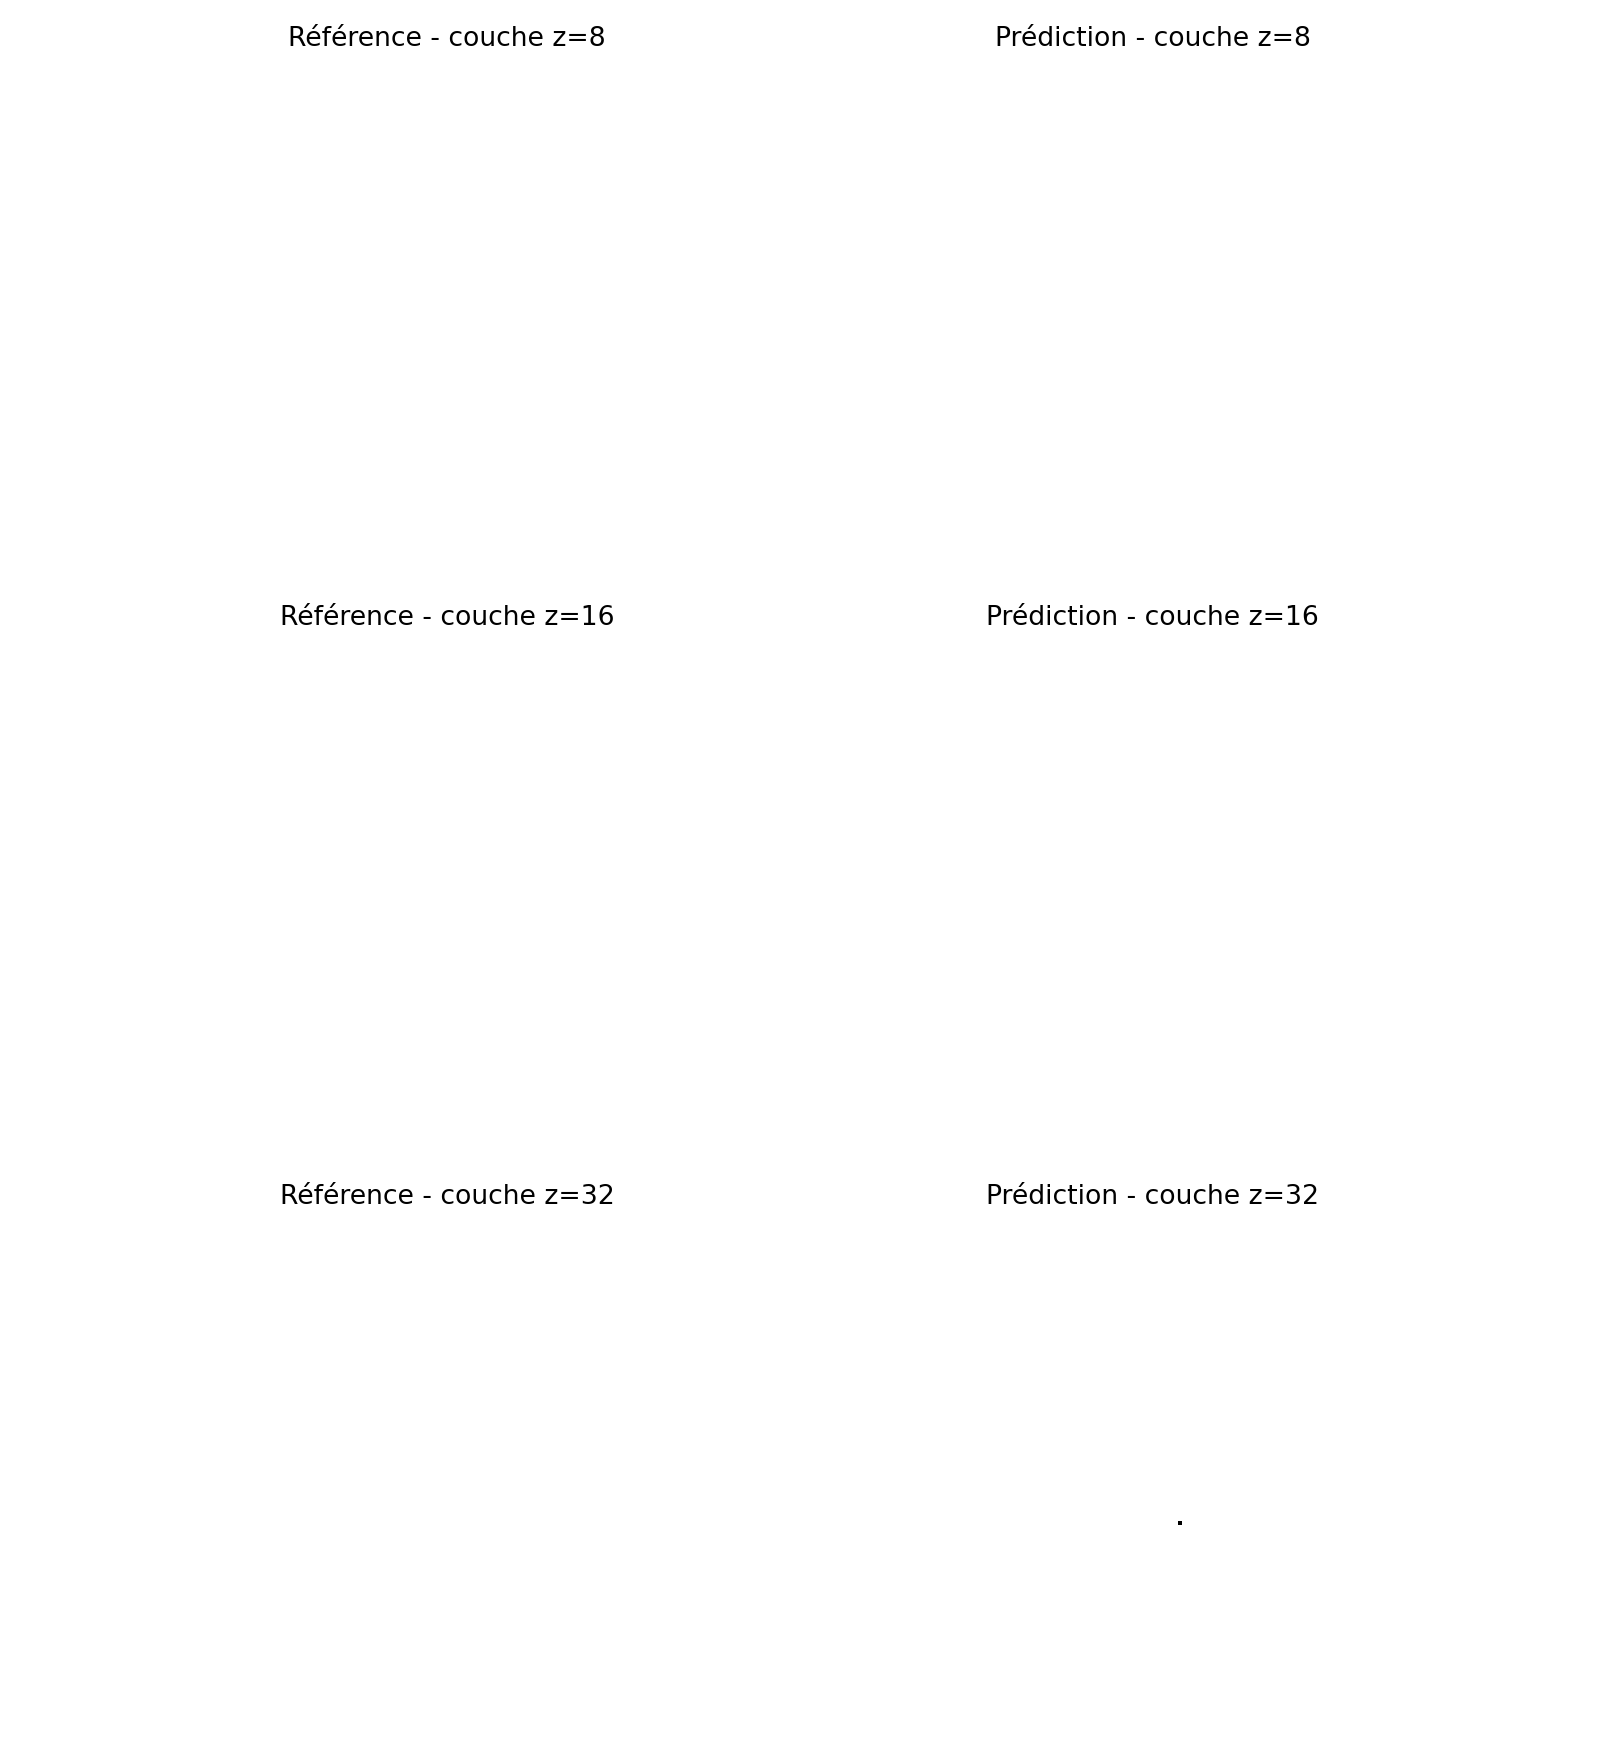


-- renders_grid.png


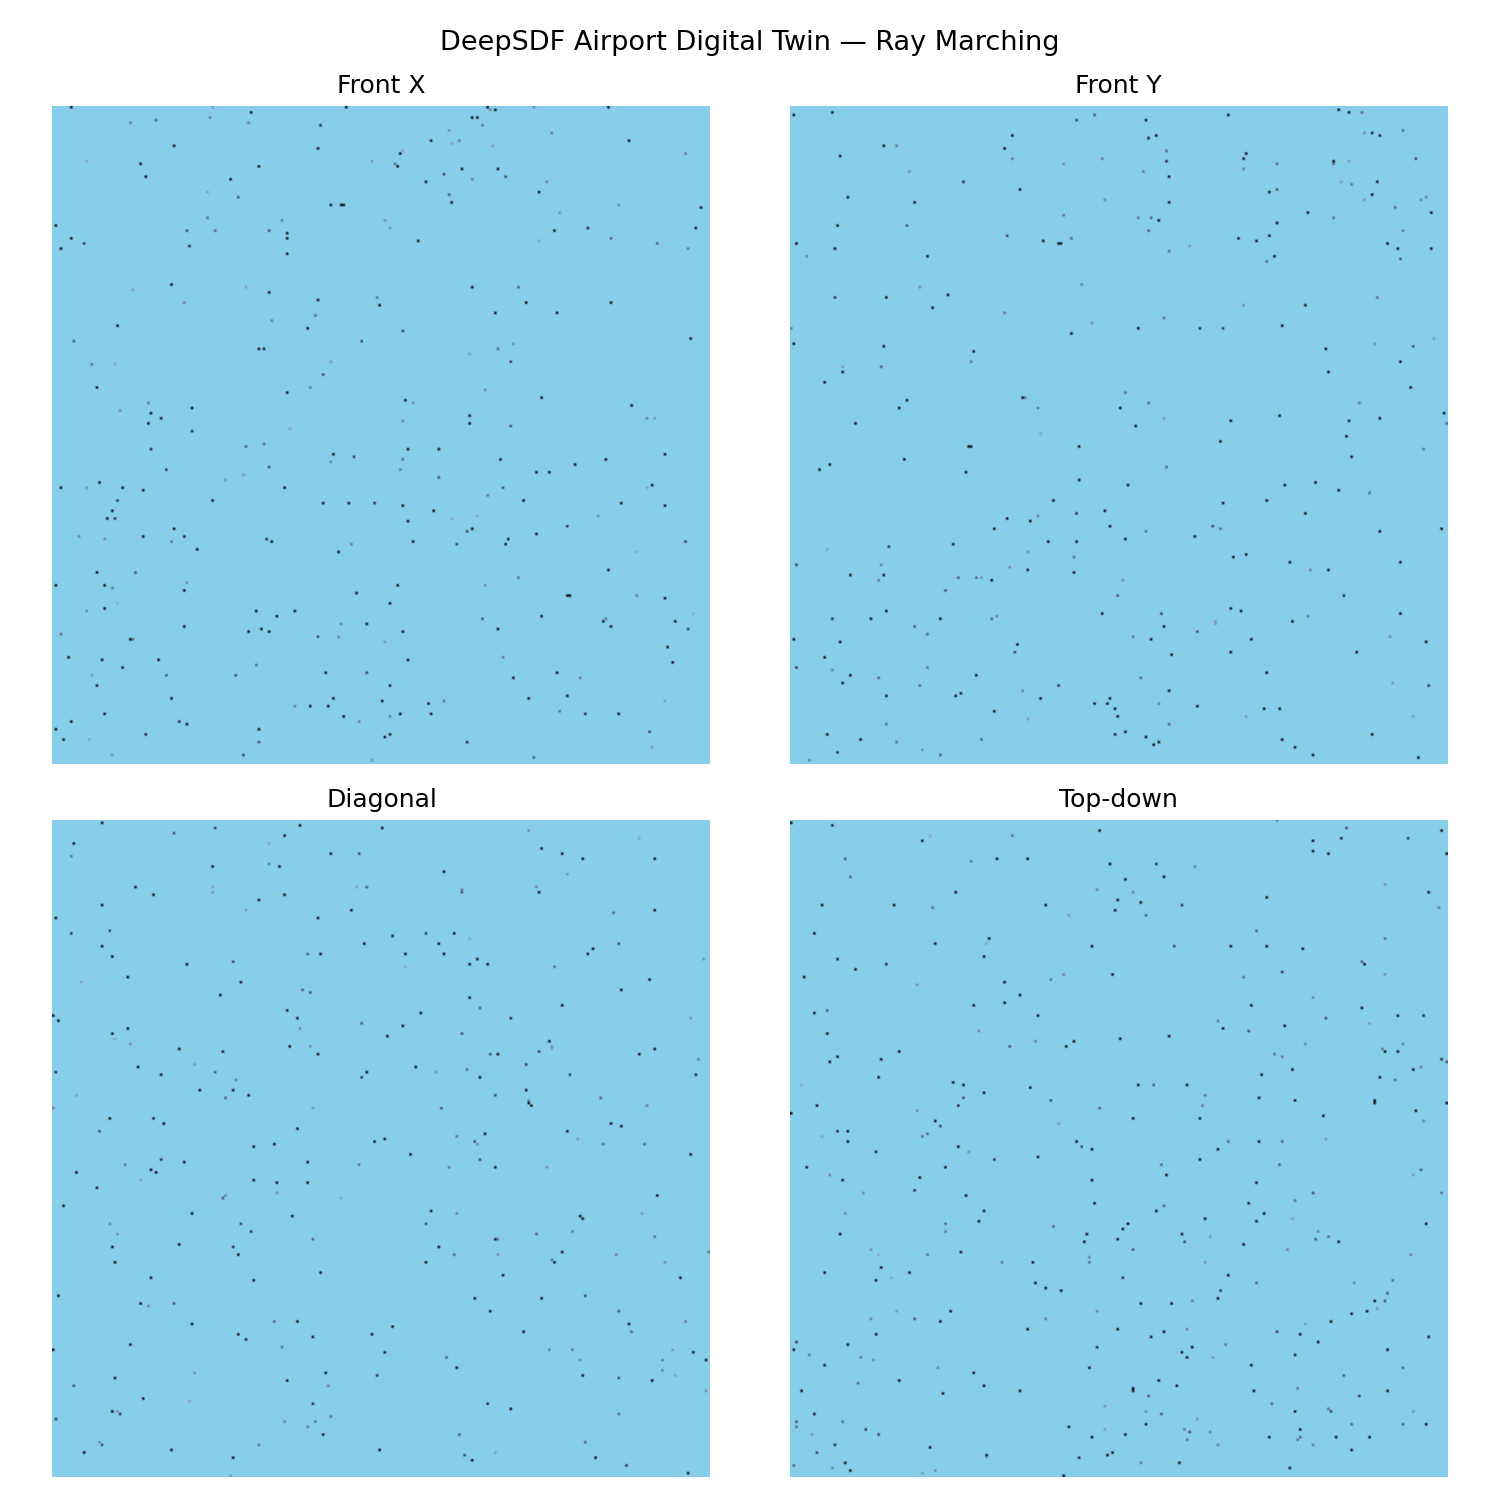


-- sdf_slice_z005.png


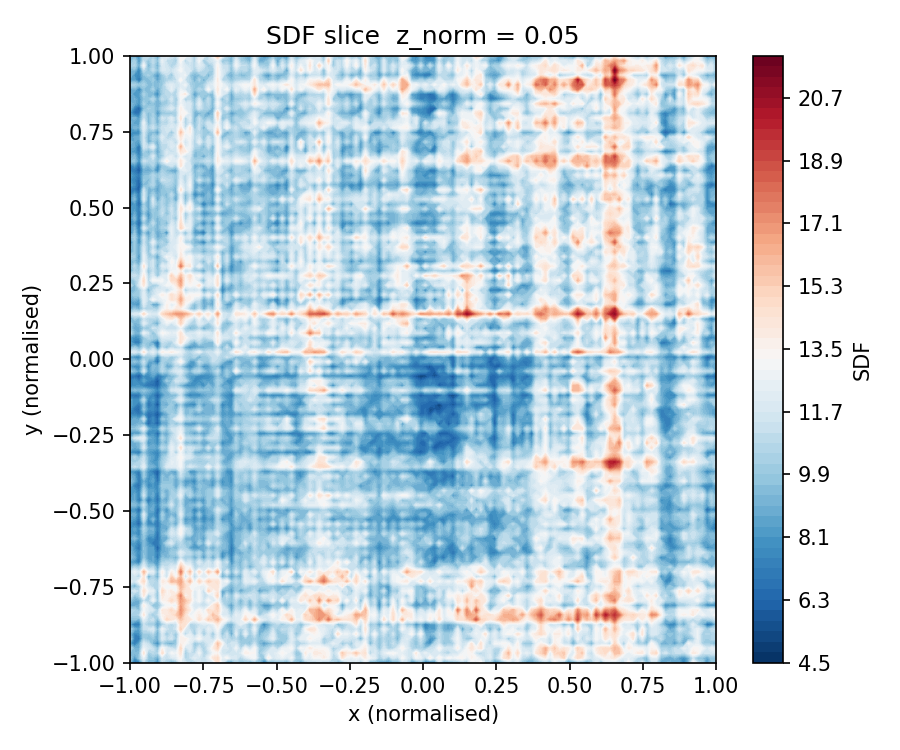


-- sdf_slice_z020.png


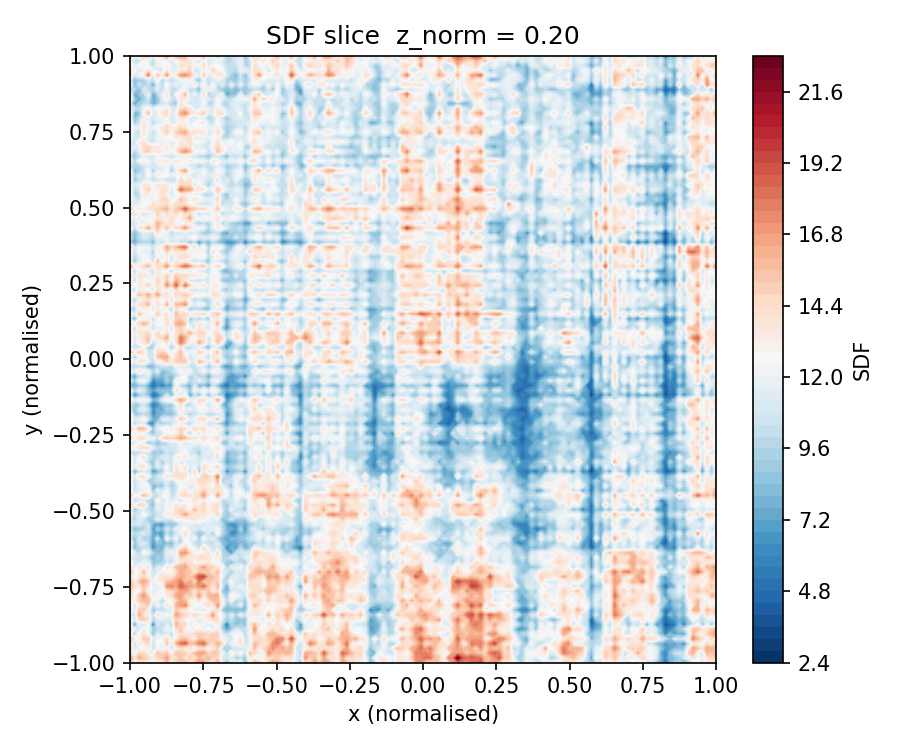


-- sdf_slice_z050.png


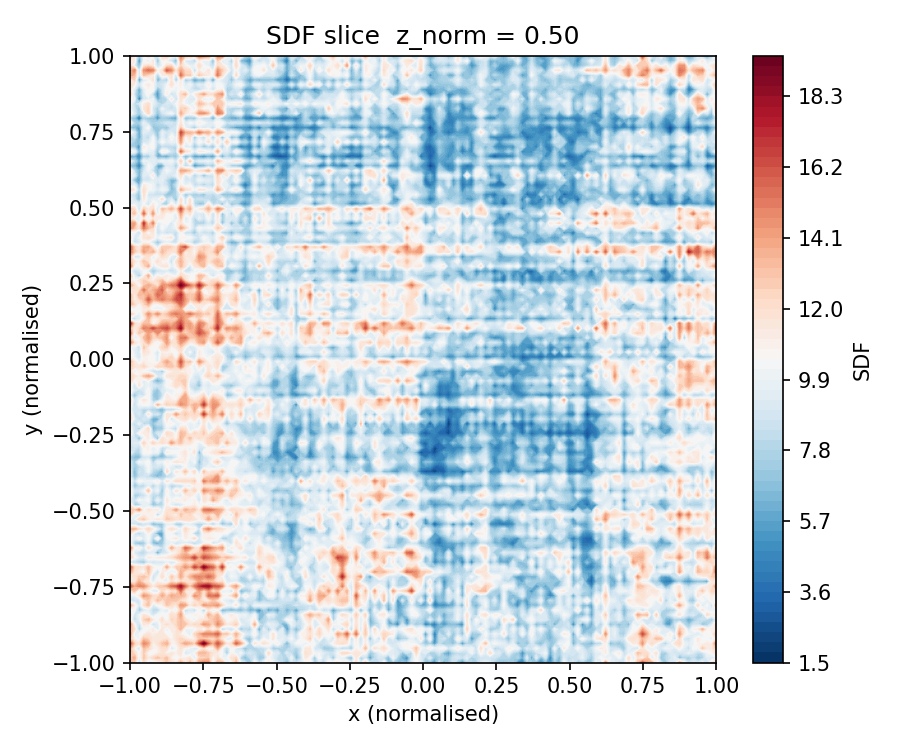

In [12]:
from pathlib import Path
from IPython.display import Image, display
import json

metrics_path = Path("outputs/reconstruction_metrics.json")
if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)
    print("Métriques de reconstruction :")
    for k, v in metrics.items():
        print(f"  {k}: {v}")
else:
    print("reconstruction_metrics.json introuvable")

ref_summary = Path("data/meshes/openalaqs_reference_layers.json")
if ref_summary.exists():
    print("\nRéférence OpenALAQS détectée :", ref_summary)

for fname in [
    "training_loss.png",
    "reconstruction_comparison.png",
    "renders_grid.png",
    "sdf_slice_z005.png",
    "sdf_slice_z020.png",
    "sdf_slice_z050.png",
]:
    path = Path("outputs") / fname
    if path.exists():
        print("\n--", fname)
        display(Image(filename=str(path), width=700))


## Cell 12 - Génération du masque d'obstacles

Le masque produit ici correspond à l'étape de sortie géométrique exploitable pour la suite physique.


In [19]:
!python generate_mask.py --config {CONFIG_FILE} --checkpoint checkpoints/best.pt


Device: cuda

=== Generating obstacle mask ===
  Grid: 64×140×140 = 1,254,400 cells
  Obstacle cells: 18,101 / 1,254,400  (1.4%)
  Grid spacing  : dx=21.58 m, dy=21.58 m, dz=3.17 m
  Mask saved → /content/deepsdf_airport/outputs/obstacle_mask.pt  shape=(1, 1, 64, 140, 140)
  SDF grid saved → /content/deepsdf_airport/outputs/sdf_grid.npy
  Mask metadata saved → /content/deepsdf_airport/outputs/obstacle_mask_metadata.json
  Mask slice → /content/deepsdf_airport/outputs/mask_slice_z5pct.png
  Mask slice → /content/deepsdf_airport/outputs/mask_slice_z25pct.png
  Mask slice → /content/deepsdf_airport/outputs/mask_slice_z50pct.png

COPY-PASTE: how to use with wind.py

import sys, torch
sys.path.insert(0, r"/content/deepsdf_airport/prof_files")
from wind import MassConsistentWindSolverNumerical

mask = torch.load(r"/content/deepsdf_airport/outputs/obstacle_mask.pt").cuda()        # (1,1,64,140,140)

dx, dy, dz = 21.58, 21.58, 3.17       # metres
solver = MassConsistentWindSolverNumerical(dx=d

## Cell 12b - Contrôle qualité du pipeline

Cette étape vérifie les sorties essentielles attendues : métriques de reconstruction, mesh reconstruit, vidéo, masque d'obstacles et, si présent, export de référence OpenALAQS.


In [20]:
from pathlib import Path
import json
import torch

outputs_dir = Path("outputs")
required_paths = [
    outputs_dir / "reconstructed_mesh.obj",
    outputs_dir / "reconstruction_metrics.json",
    outputs_dir / "renders_grid.png",
    outputs_dir / "flyover.mp4",
    outputs_dir / "obstacle_mask.pt",
]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    print("Sorties manquantes :")
    for p in missing:
        print("  -", p)
else:
    print("Toutes les sorties principales sont présentes.")

metrics_path = outputs_dir / "reconstruction_metrics.json"
if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        metrics = json.load(f)
    print("\nMétriques principales :")
    for key in ["chamfer_l1_m", "hausdorff_approx_m", "occupancy_iou", "occupancy_precision", "occupancy_recall"]:
        if key in metrics:
            print(f"  {key}: {metrics[key]}")

mask_path = outputs_dir / "obstacle_mask.pt"
if mask_path.exists():
    mask = torch.load(mask_path, map_location="cpu")
    obstacle_voxels = int((mask < 0.5).sum().item())
    total_voxels = int(mask.numel())
    print(f"\nObstacle voxels: {obstacle_voxels} / {total_voxels}")
    if obstacle_voxels == 0:
        print("ATTENTION: masque vide.")
    else:
        print("Masque non vide.")


Toutes les sorties principales sont présentes.

Métriques principales :
  chamfer_l1_m: 151.13709168237895
  hausdorff_approx_m: 695.3502749334696
  occupancy_iou: 0.13886615376220876
  occupancy_precision: 0.14059996685266007
  occupancy_recall: 0.9184409960303139

Obstacle voxels: 18101 / 1254400
Masque non vide.


## Cell 13 - Test d'intégration avec wind.py

Cette cellule vérifie que le masque généré peut être chargé dans le solveur de vent fourni.


In [21]:
import os
import sys
import torch
import yaml
from pathlib import Path

prof_dir = Path("prof_files")
if not (prof_dir / "wind.py").exists():
    print("wind.py introuvable dans prof_files")
else:
    sys.path.insert(0, str(prof_dir))
    from wind import MassConsistentWindSolverNumerical

    mask_path = Path("outputs/obstacle_mask.pt")
    if not mask_path.exists():
        raise FileNotFoundError(mask_path)

    mask = torch.load(mask_path, map_location="cpu")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    mask = mask.to(device)

    with open(CONFIG_FILE, "r", encoding="utf-8") as f:
        cfg = yaml.safe_load(f)
    d = cfg["domain"]
    dx = (d["x_max"] - d["x_min"]) / (d["grid_nx"] - 1)
    dy = (d["y_max"] - d["y_min"]) / (d["grid_ny"] - 1)
    dz = d["z_max"] / (d["grid_nz"] - 1)

    solver = MassConsistentWindSolverNumerical(dx=dx, dy=dy, dz=dz, device=device)
    u0 = torch.full_like(mask, 5.0)
    v0 = torch.zeros_like(mask)
    w0 = torch.zeros_like(mask)
    u, v, w, sigma, K = solver.adjust_wind_field(u0, v0, w0, mask)

    print("Test d'intégration terminé")
    print("  shape u :", tuple(u.shape))
    print("  max |u| :", float(u.abs().max().item()))


Test d'intégration terminé
  shape u : (1, 1, 64, 140, 140)
  max |u| : nan


## Cell 14 - Bilan des livrables produits

Cette dernière cellule récapitule les sorties principales du pipeline.


In [22]:
from pathlib import Path

outputs = sorted(str(p) for p in Path("outputs").glob("*"))
checkpoints = sorted(str(p) for p in Path("checkpoints").glob("*.pt"))
mesh_refs = sorted(str(p) for p in Path("data/meshes").glob("openalaqs_reference_layers.*"))

print("Sorties :")
for p in outputs:
    print("  ", p)

print("\nCheckpoints :")
for p in checkpoints:
    print("  ", p)

if mesh_refs:
    print("\nRéférences OpenALAQS :")
    for p in mesh_refs:
        print("  ", p)


Sorties :
   outputs/flyover.mp4
   outputs/mask_slice_z25pct.png
   outputs/mask_slice_z50pct.png
   outputs/mask_slice_z5pct.png
   outputs/obstacle_mask.pt
   outputs/obstacle_mask_metadata.json
   outputs/reconstructed_mesh.obj
   outputs/reconstruction_comparison.png
   outputs/reconstruction_metrics.json
   outputs/render_Diagonal.png
   outputs/render_Front_X.png
   outputs/render_Front_Y.png
   outputs/render_Top-down.png
   outputs/renders_grid.png
   outputs/sdf_grid.npy
   outputs/sdf_slice_z005.png
   outputs/sdf_slice_z020.png
   outputs/sdf_slice_z050.png

Checkpoints :
   checkpoints/best.pt
   checkpoints/checkpoint_epoch_0050.pt
   checkpoints/checkpoint_epoch_0100.pt
   checkpoints/checkpoint_epoch_0150.pt
   checkpoints/checkpoint_epoch_0200.pt
   checkpoints/checkpoint_epoch_0250.pt
   checkpoints/checkpoint_epoch_0300.pt
   checkpoints/checkpoint_epoch_0350.pt
   checkpoints/checkpoint_epoch_0400.pt
   checkpoints/checkpoint_epoch_0450.pt
   checkpoints/last.pt

Ré

## Cell 15 - Sauvegarde finale vers Drive

Si le notebook est lancé depuis Colab avec `USE_GOOGLE_DRIVE = True`, cette cellule recopie les sorties finales ainsi que l'étude `.alaqs` utilisée dans le dossier Drive du projet.


In [23]:
from pathlib import Path
import shutil
import yaml

if IN_COLAB and USE_GOOGLE_DRIVE:
    drive_root = Path(DRIVE_PROJECT_DIR)
    for sub in ["outputs", "checkpoints"]:
        src = WORK_DIR / sub
        dst = drive_root / sub
        if dst.exists():
            shutil.rmtree(dst)
        if src.exists():
            shutil.copytree(src, dst)

    with open(CONFIG_FILE, "r", encoding="utf-8") as f:
        selected_cfg = yaml.safe_load(f)
    airport_cfg = selected_cfg.get("airport", {})
    openalaqs_rel = airport_cfg.get("open_alaqs_database", "") or airport_cfg.get("open_alaqs_study", "")

    extra_files = [
        WORK_DIR / "data/meshes/metadata.json",
        WORK_DIR / "data/meshes/buildings_2d.json",
        WORK_DIR / "data/meshes/openalaqs_reference_layers.json",
        WORK_DIR / "data/meshes/openalaqs_reference_layers.geojson",
        WORK_DIR / "data/sdf_dataset/normalization.json",
        WORK_DIR / CONFIG_FILE,
    ]
    if openalaqs_rel:
        extra_files.append(WORK_DIR / openalaqs_rel)

    for path in extra_files:
        if path.exists():
            rel = path.relative_to(WORK_DIR)
            out = drive_root / rel
            out.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(path, out)

    print("Sauvegarde Drive terminée.")
else:
    print("Sauvegarde Drive ignorée (mode local ou Drive désactivé).")


Sauvegarde Drive terminée.
